# Test statistics and the likelihood ratio test

You have collected some data with a particle collider experiment at CERN. In particular, you are measuring an angle between 0 and $\pi$ and you expect to have a flat uniform background.  
There are two different signal hypothesis and you are collecting data to take 2 decisions:
1) is the data compatible with the bkg-only hypotheses?
2) if the data is not compatible with the bkg-only hypothesis with a **99% significance level** --> then which of the two signal hypothesis is more probable?
Recall that 99% significance level means that the probability to commit a type I error is 1%

The shape of the two signal hypothesis has been simulated with Monte Carlo (MC) and it is given to you in the form of "simulated events". You can find the value of the simulated angles in the files "MC_signal_1" and "MC_signal_2".
So we don't have an analytical expression for the pdf of the angle under the two alternative hypotheses but we have data that were sampled from those pdf.
We assume those data are enough to fully characterize the pdfs.

The total number of expected events for background and signal depends on their "cross-section" (XS) (their probability of happening) and by the "luminosity" of your experiment (roughly how many times you make particles collide to perform this experiment).  
You can compute the expected number of events by $ N = \mathcal{L} * XS$.
The XS of the **background is 1 pb** (picobarn) whereas the expected XS of the **signal is 0.1 pb** for both the hypothesis.
From my understanding, this information is telling us the signal to background ratio $f_{sig}$ so we don't have to fit also this parameter; if this was not the case, we would have had different luminosities for signal and background, in that case, this piece of info would have linked the $f_{sig}$ to the number of expected events $N = \mathcal{L}_{sig}*0.1+\mathcal{L}_{bkg}*1 = f_{sig}\mathcal{L}*0.1+(1-f_{sig})\mathcal{L}*1 $?  
The measured data is given to you in "data_lumi_LUMI.0.npy" files, corresponding to the datata collected for increasing luminosities  [1e2, 5e2, 1e3, 5e3, 1e4, 5e4, 1e5] #/pb.

## Exercise 1.1

- Plot the expected sig+bkg distribution and the recorded data for the two signal hypothesis, for different collected luminosity values.  ([1e2, 5e2, 1e3, 5e3, 1e4, 5e4, 1e5] #/pb.)

- Build a binned likelihood for the signal + background model.
  - vary the number of bins: [2, 5, 10, 20, 30] 
  - Plot the likelihood of observing the data for the datasets collected with increasing luminosity (more and more data collected). What do you observe?
  - Plot the likelihood increasing the number of bins


In [136]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import pandas as pd
from tqdm import tqdm
import seaborn as sns
from multiprocessing import Pool, cpu_count, set_start_method
set_start_method("fork", force=True)
np.random.seed(27)

signal_pdf = {'1': np.load('MC_signal_1.npy'),
              '2': np.load('MC_signal_2.npy'),
             }
# To treat the background in the same way I can treat the signal, I create an array with the same dimension of the
# signal arrays containing "simulated events" for the background which are nothing but uniform random numbers extracted
# between 0 and pi
background_pdf = np.random.uniform(size = len(signal_pdf['1'])) * np.pi

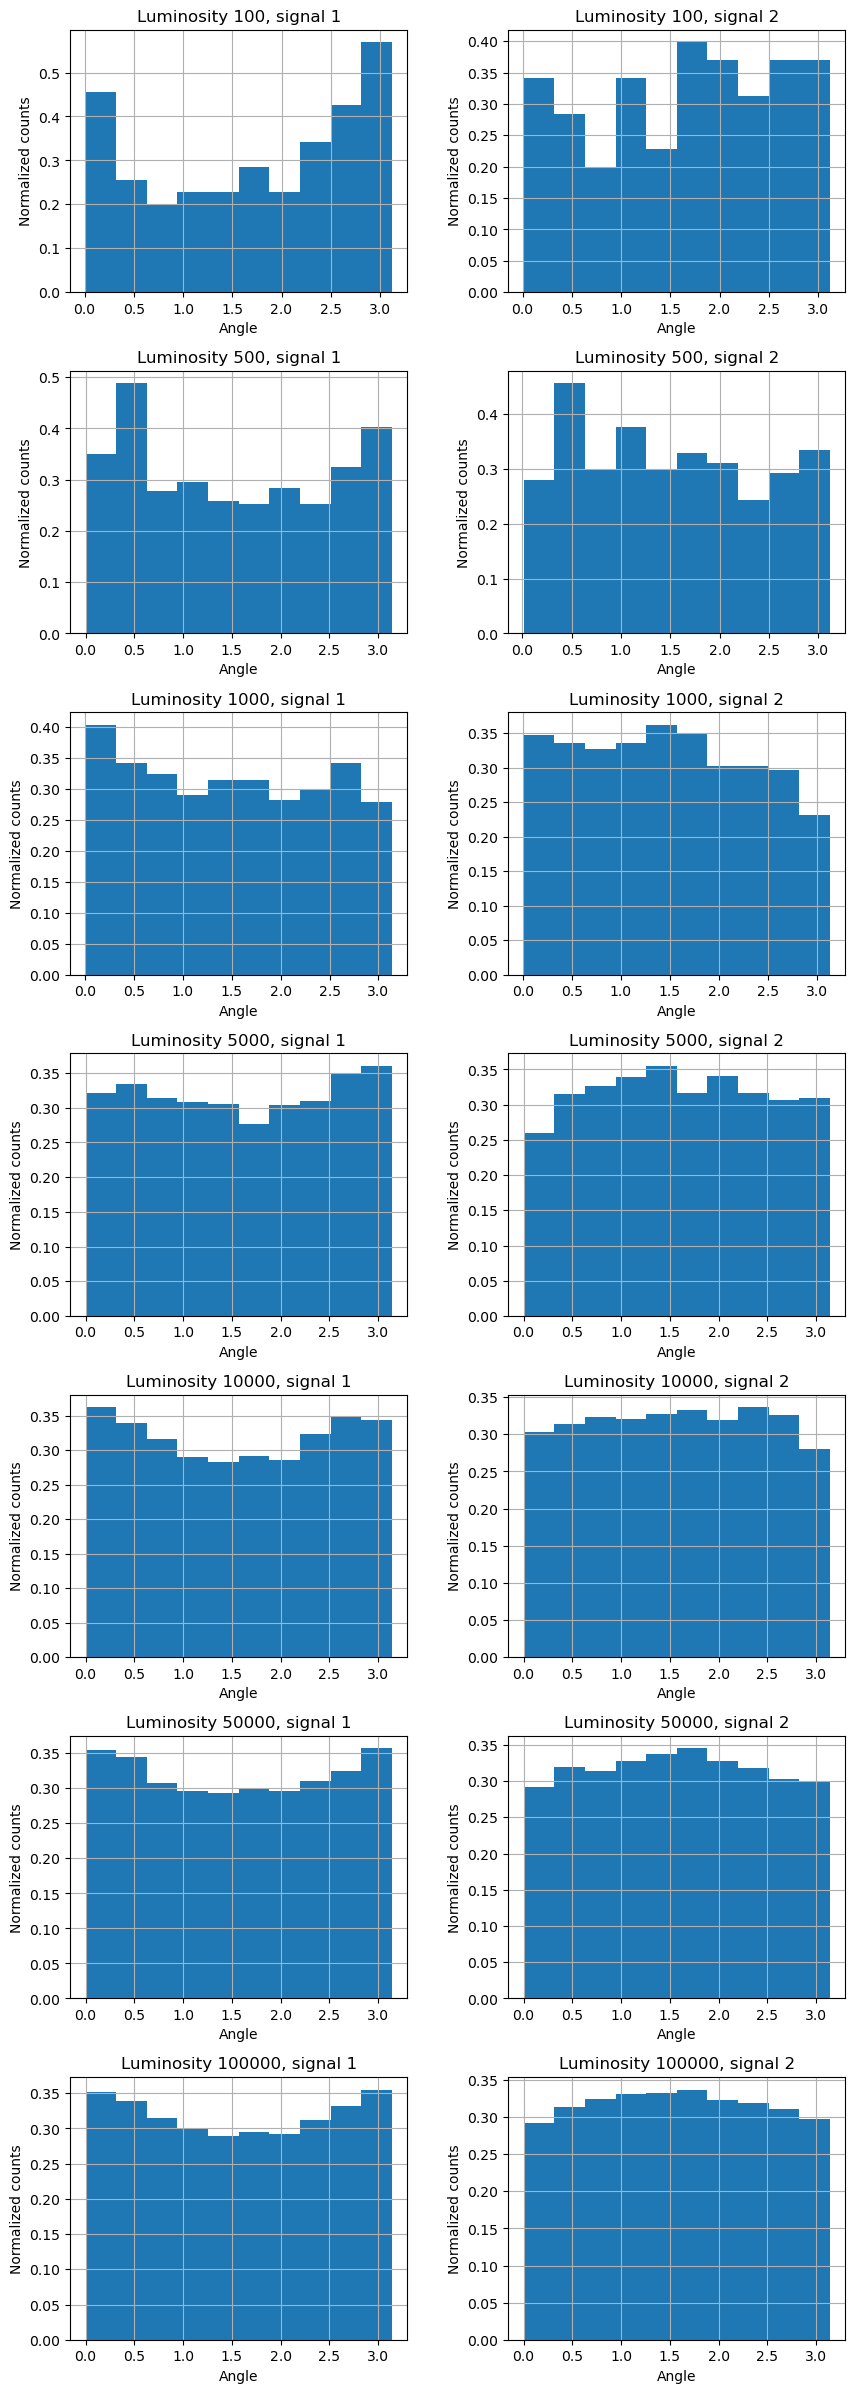

In [125]:
# In the case of luminosity L, we expect N_bkg = L events for the background, and N_sig = L*0.1 for the signal. Both
# numbers of actually measured events follow, separately, a Poisson distributino with those values as means.
np.random.seed(27)
luminosities = [100, 500, 1000, 5000, 10000, 50000, 100000]

fig, ax = plt.subplots(len(luminosities), 2, figsize=(10,30))
fig.subplots_adjust(wspace=0.3, hspace=0.3)

for i, lumi in enumerate(luminosities):
    N_bkg = np.random.poisson(lam=lumi)
    N_sig = np.random.poisson(lam=lumi*0.1)

    bkg  = np.random.choice(background_pdf,  size=N_bkg)
    sig1 = np.random.choice(signal_pdf['1'], size=N_sig)
    sig2 = np.random.choice(signal_pdf['2'], size=N_sig)

    tot = np.concatenate((bkg, sig1))
    ax[i][0].hist(tot, density=True)
    ax[i][0].set_xlabel('Angle')
    ax[i][0].set_ylabel('Normalized counts')
    ax[i][0].set_title(f'Luminosity {lumi}, signal 1')
    ax[i][0].grid(True)

    tot = np.concatenate((bkg, sig2))
    ax[i][1].hist(tot, density=True)
    ax[i][1].set_xlabel('Angle')
    ax[i][1].set_ylabel('Normalized counts')
    ax[i][1].set_title(f'Luminosity {lumi}, signal 2')
    ax[i][1].grid(True)
    
    

In [126]:
@dataclass
class binned_ENLL:
    data:           np.ndarray
    background_pdf: np.ndarray
    signal_pdf:     np.ndarray
    luminosity:     float

    # To build the combined model bkg+sig I don't want to waste any data contained in the simulation of the signal,
    # so I assume a fictional luminosity that is 10 times the number of elements in the signal_pdf
    def __post_init__(self):
        if np.array_equal(self.signal_pdf, np.zeros(len(self.signal_pdf))): #when testing H0 I'll give an array of zeros
            self.model      = self.background_pdf
            self.expected_N = self.luminosity
        else:
            self.model  = np.concatenate((np.random.choice(self.background_pdf, size=10*len(self.signal_pdf)), self.signal_pdf))
            self.expected_N = self.luminosity + 0.1*self.luminosity
    

    def __call__(self, bin_number):
        binned_data  = np.histogram(self.data,  bins=bin_number)[0]
        binned_model = np.histogram(self.model, bins=bin_number)[0]/len(self.model) #normalized binned model: the bin value it's already the probability of falling in the corresponding bin

        # The two terms, the contribution of the total number of events and the contribution of the statistics in the bins
        # can be combined simplifying the calculation. See iPad "SMATEP - Ex05" for the details
        ENLL = self.expected_N - len(self.data)*np.log(self.expected_N)
        for i, N_i in enumerate(binned_data):
            ENLL += -N_i*np.log(binned_model[i])
            while N_i > 0: #to avoid crazy high numbers with the factorial
                ENLL += np.log(N_i)
                N_i -= 1

        return ENLL

In [127]:
# data_test = np.concatenate((np.random.choice(background_pdf, 10*len(signal_pdf['1'])), signal_pdf['1']))
# test = binned_ENLL(data_test, background_pdf, signal_pdf['1'], 10*len(signal_pdf['1']))
# 
# data_counter_test = np.random.choice(background_pdf, 11*len(signal_pdf))
# counter_test = binned_ENLL(data_counter_test, background_pdf, signal_pdf['1'], 10*len(signal_pdf['1']))
# 
# print(test(50), counter_test(50))

In [128]:
bin_numbers = [2, 5, 10, 20, 30]

bENLL_results = []
for bin_number in bin_numbers:
    bENLL_results.append([])
    for lumi in luminosities:
        data = np.load('data_lumi_'+str(lumi)+'.0.npy')
    
        bENLL_H0 = binned_ENLL(data=data,
                               background_pdf=background_pdf,
                               signal_pdf=np.zeros(1), #a numpy array is needed for compatibility 
                               luminosity=lumi)
        bENLL_H1 = binned_ENLL(data=data,
                               background_pdf=background_pdf,
                               signal_pdf=signal_pdf['1'],
                               luminosity=lumi)
        bENLL_H2 = binned_ENLL(data=data,
                               background_pdf=background_pdf,
                               signal_pdf=signal_pdf['2'],
                               luminosity=lumi)
        bENLL_results[-1].append((bENLL_H0(bin_number), bENLL_H1(bin_number), bENLL_H2(bin_number)))
    
bENLL_results = np.array(bENLL_results)

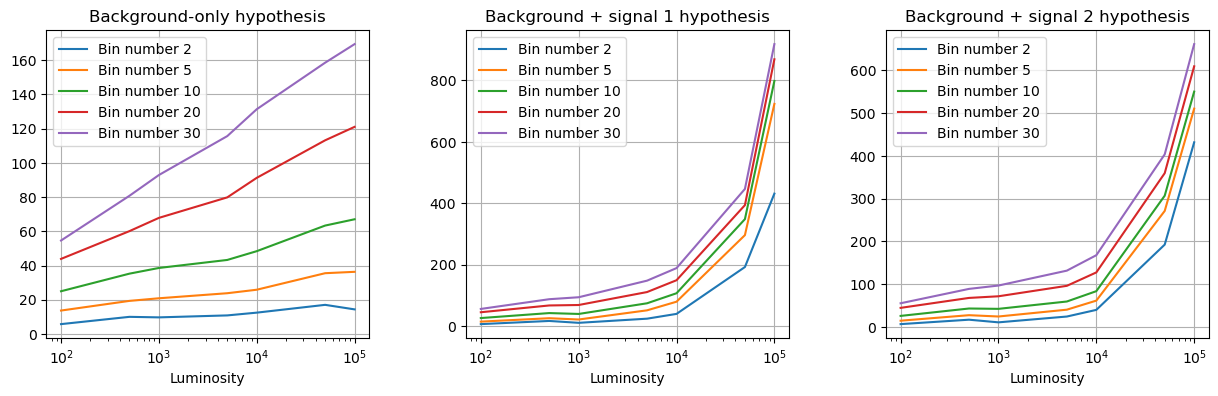

In [129]:
fig, ax = plt.subplots(1, 3, figsize=(15,4))
fig.subplots_adjust(wspace=0.3)

for i, results_fixed_bin_number in enumerate(bENLL_results):
    ax[0].plot(luminosities, results_fixed_bin_number[:,0], label=f'Bin number {bin_numbers[i]}')
    ax[1].plot(luminosities, results_fixed_bin_number[:,1], label=f'Bin number {bin_numbers[i]}')
    ax[2].plot(luminosities, results_fixed_bin_number[:,2], label=f'Bin number {bin_numbers[i]}')
ax[0].set_title('Background-only hypothesis')
ax[1].set_title('Background + signal 1 hypothesis')
ax[2].set_title('Background + signal 2 hypothesis')
for axis in ax: axis.grid(True); axis.set_xlabel('Luminosity'); axis.legend(); axis.set_xscale('log')
plt.show()
    

## Exercise 1.2

Consider the 3 hypothesis: background-only, background+sig1, background+sig2

- Build a test statistics for B vs Sig1, B vs Sig2
    - Use the **likelihood ratio** as a test statistics:
        - Plot the test statistic distribution using toys generated with the bkg-only hypothesis or with the two signal hypothesis.
        - Compute the "observed" value of the test statistics on data. What do you observe?
        - Plot the test statistics for increasing luminosity and number of bins. Which trend you can observe?
    - Compute the test statistic power and significance with a varying luminosity. How much are the Type I and Type II errors for the two tests?

In [131]:
@dataclass
class throw_toy:
    background_pdf: np.ndarray
    signal_pdf:     dict

    def __call__(self, luminosity, bin_number):
        N_sig = np.random.poisson(luminosity*0.1)
        sig1  = np.random.choice (self.signal_pdf['1'], size=N_sig)
        sig2  = np.random.choice (self.signal_pdf['2'], size=N_sig)
        
        N_bkg = np.random.poisson(luminosity)
        bkg   = np.random.choice (self.background_pdf,  size=N_bkg)
    
        toy1 = np.concatenate((bkg, sig1))
        toy2 = np.concatenate((bkg, sig2))

        bENLL_H0 = binned_ENLL(data=bkg,
                                   background_pdf = self.background_pdf,
                                   signal_pdf     = np.zeros(1), #a numpy array is needed for compatibility 
                                   luminosity     = luminosity)
        bENLL_H1 = binned_ENLL(data=toy1,
                                   background_pdf = self.background_pdf,
                                   signal_pdf     = self.signal_pdf['1'],
                                   luminosity     = luminosity)
        bENLL_H2 = binned_ENLL(data=toy2,
                                   background_pdf = self.background_pdf,
                                   signal_pdf     = self.signal_pdf['2'],
                                   luminosity     = luminosity)
        
        LR_H0_H1 = np.exp(-bENLL_H1(bin_number))/np.exp(-bENLL_H0(bin_number))
        LR_H0_H2 = np.exp(-bENLL_H2(bin_number))/np.exp(-bENLL_H0(bin_number))

        return LR_H0_H1, LR_H0_H2

In [135]:
np.random.seed(27)
LR_H0_H1 = pd.DataFrame(index=bin_numbers, columns=luminosities)
LR_H0_H2 = pd.DataFrame(index=bin_numbers, columns=luminosities)

throw = throw_toy(background_pdf = background_pdf,
                  signal_pdf     = signal_pdf
                 )

n_toys = int(1e3)
for lumi in luminosities:
    for bin_number in tqdm(bin_numbers, desc=f'Computing luminosity {lumi}'):
        with Pool(cpu_count()-2) as pool:
            results = pool.starmap(throw, [(lumi,bin_number) for _ in range(n_toys)])
        
        results  = np.array(results)
        LR_H0_H1.loc[bin_number, lumi] = results[:,0]
        LR_H0_H2.loc[bin_number, lumi] = results[:,1]

Computing luminosity 100000: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [06:30<00:00, 78.11s/it]


(0.0, 2.0)

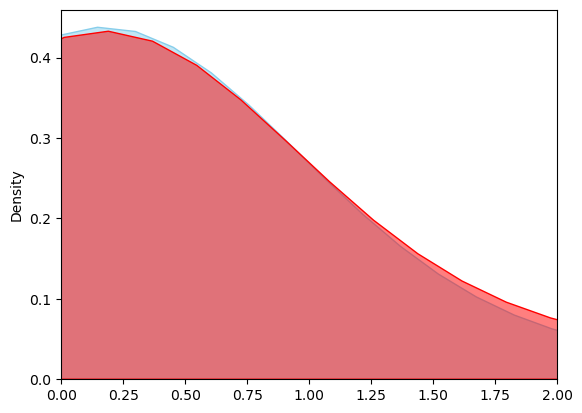

In [151]:
sns.kdeplot(LR_H0_H1.loc[bin_numbers[-1], luminosities[-1]], bw_adjust=1, fill=True, color='skyblue', alpha=0.5)
sns.kdeplot(LR_H0_H2.loc[bin_numbers[-1], luminosities[-1]], bw_adjust=1, fill=True, color='red', alpha=0.5)
plt.xlim((0,2))

## Exercise2

Build an hypothesis test to choose one of the signal hypothesis. 
- Quantify the p-value of the incompatibility of data with the sig1 (or sig2) varying the luminosity and number of bins.
- What is the best number of bins to discriminate the two signal hypothesis?

## Exercise 3 (extra)

Invent a test statistics (e.g. the ratio of the number of events with ($|\theta - \pi/2|>0.5$ and the $|\theta - \pi/2|<0.5$ ) and compare is power with the likelihood ratio at fixed significance of 99%.